In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q torch-geometric
!pip install -q rdkit
!pip install -q scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 18.4 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, NNConv

from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
def load_data(name):
    dataset = MoleculeNet(root='data', name=name)
    dataset = dataset.shuffle()

    train = dataset[:int(0.8 * len(dataset))]
    test  = dataset[int(0.8 * len(dataset)):]

    return (
        DataLoader(train, batch_size=64, shuffle=True),
        DataLoader(test, batch_size=64),
        dataset
    )

In [15]:
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, NNConv
import torch
import torch.nn.functional as F

# ✅ GCN
class GCN(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 64)
        self.conv2 = GCNConv(64, 64)
        self.lin = torch.nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)


# ✅ GAT
class GAT(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, 64)
        self.conv2 = GATConv(64, 64)
        self.lin = torch.nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)


# ✅ MPNN
class MPNN(torch.nn.Module):
    def __init__(self, in_channels, edge_dim):
        super().__init__()

        nn = torch.nn.Sequential(
            torch.nn.Linear(edge_dim, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, in_channels * 64)
        )

        self.conv = NNConv(in_channels, 64, nn)
        self.lin = torch.nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x.float(), data.edge_index, data.edge_attr.float(), data.batch
        x = F.relu(self.conv(x, edge_index, edge_attr))
        x = global_mean_pool(x, batch)
        return self.lin(x)

In [5]:
datasets = ["ESOL", "FreeSolv", "Lipophilicity"]
models = {"GCN": GCN, "GAT": GAT, "MPNN": MPNN}

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train(model, loader, optimizer):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = model(data)
        loss = F.mse_loss(out, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    actual, pred = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)

            actual.extend(data.y.view(-1).cpu().numpy())
            pred.extend(out.view(-1).cpu().numpy())

    actual = np.array(actual)
    pred = np.array(pred)

    rmse = np.sqrt(((actual - pred)**2).mean())
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)

    return rmse, mae, r2, actual, pred

In [9]:
def train(model, loader, optimizer):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = model(data)

        # 🔥 FIX: match shapes
        y = data.y.view(-1, 1).float()

        loss = F.mse_loss(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [21]:
datasets = ["esol", "freesolv", "lipo"]
models = {"GCN": GCN, "GAT": GAT, "MPNN": MPNN}

results = {}

for dname in datasets:
    print(f"\n===== Dataset: {dname.capitalize()} ====")

    train_loader, test_loader, dataset = load_data(dname)

    results[dname] = {}

    for mname, ModelClass in models.items():
        print(f"\n--- Model: {mname} ---")

        if mname == "MPNN":
            model = ModelClass(dataset.num_features, dataset.num_edge_features).to(device)
        else:
            model = ModelClass(dataset.num_features).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        losses = []

        for epoch in range(1, 16):
            loss = train(model, train_loader, optimizer)
            losses.append(loss)

        rmse, mae, r2, actual, pred = evaluate(model, test_loader)

        print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

        results[dname][mname] = (losses, actual, pred)


===== Dataset: Esol ====

--- Model: GCN ---
RMSE: 1.9259, MAE: 1.5306, R2: 0.1392

--- Model: GAT ---
RMSE: 1.9278, MAE: 1.5355, R2: 0.1375

--- Model: MPNN ---
RMSE: 1.6979, MAE: 1.3297, R2: 0.3310

===== Dataset: Freesolv ====

--- Model: GCN ---
RMSE: 3.8274, MAE: 2.8931, R2: 0.0254

--- Model: GAT ---
RMSE: 3.5558, MAE: 2.7562, R2: 0.1589

--- Model: MPNN ---
RMSE: 3.1570, MAE: 2.3421, R2: 0.3370

===== Dataset: Lipo ====


Processing...
Done!



--- Model: GCN ---
RMSE: 1.1737, MAE: 0.9634, R2: 0.0518

--- Model: GAT ---
RMSE: 1.1803, MAE: 0.9361, R2: 0.0410

--- Model: MPNN ---
RMSE: 1.2401, MAE: 0.9593, R2: -0.0587


In [20]:
import torch_geometric
print(torch_geometric.datasets.MoleculeNet.names.keys())

dict_keys(['esol', 'freesolv', 'lipo', 'pcba', 'muv', 'hiv', 'bace', 'bbbp', 'tox21', 'toxcast', 'sider', 'clintox'])


In [14]:
print(f"Target variable (dataset.y) dtype: {dataset.y.dtype}")
print(f"Target variable (dataset.y) shape: {dataset.y.shape}")

Target variable (dataset.y) dtype: torch.float32
Target variable (dataset.y) shape: torch.Size([1128, 1])


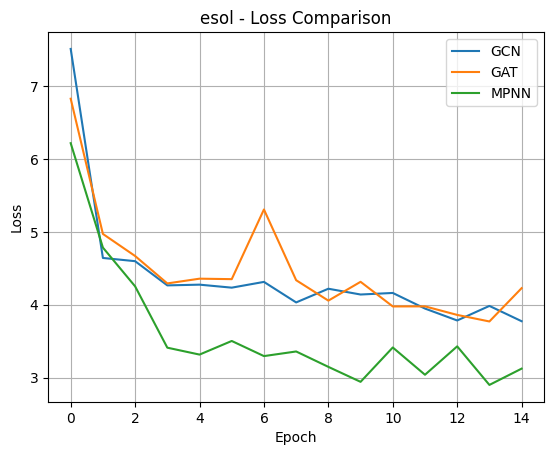

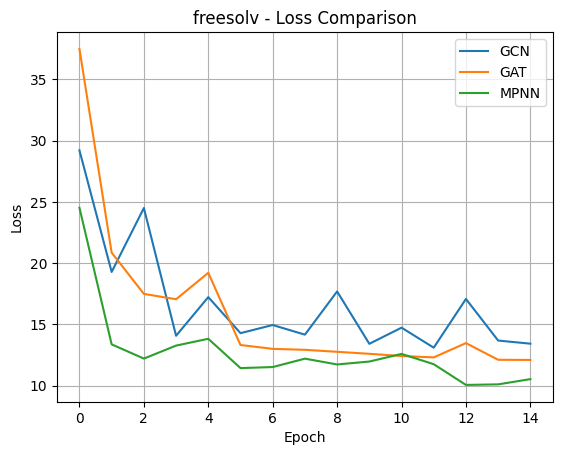

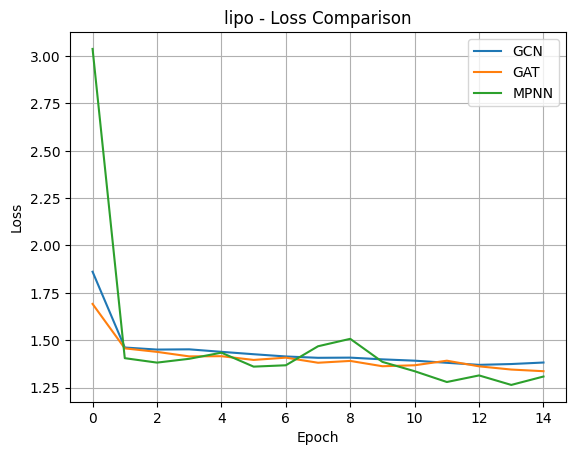

In [22]:
for dname in results:
    plt.figure()

    for mname in results[dname]:
        losses = results[dname][mname][0]
        plt.plot(losses, label=mname)

    plt.title(f"{dname} - Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

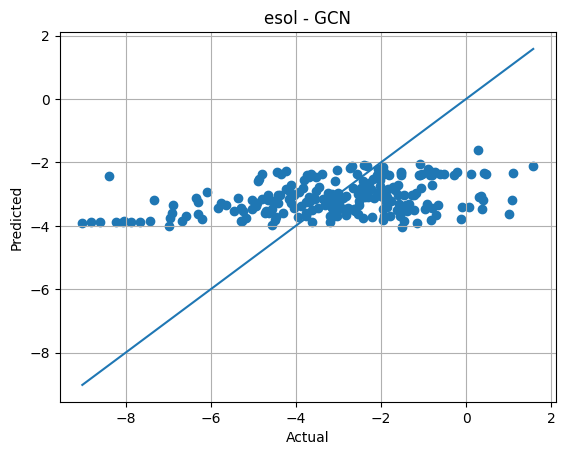

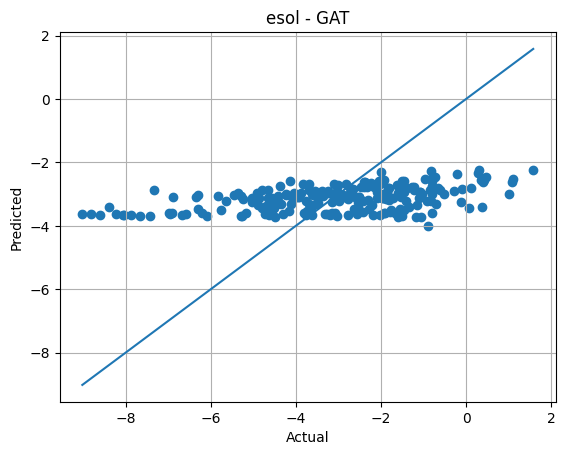

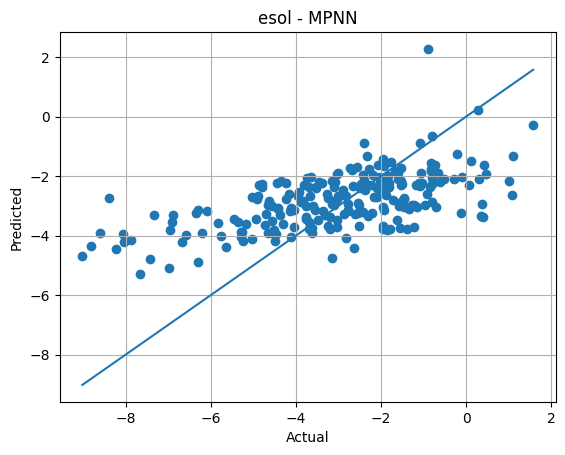

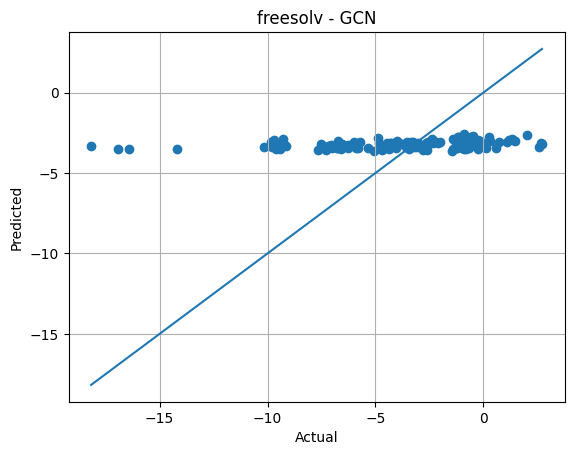

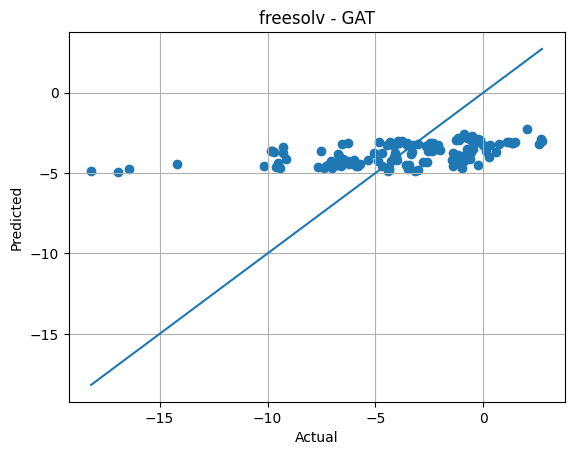

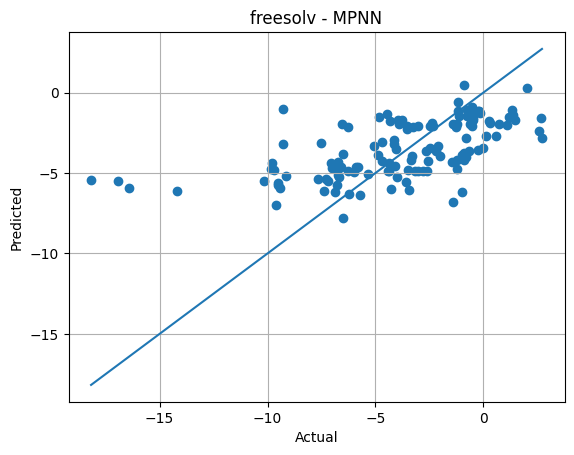

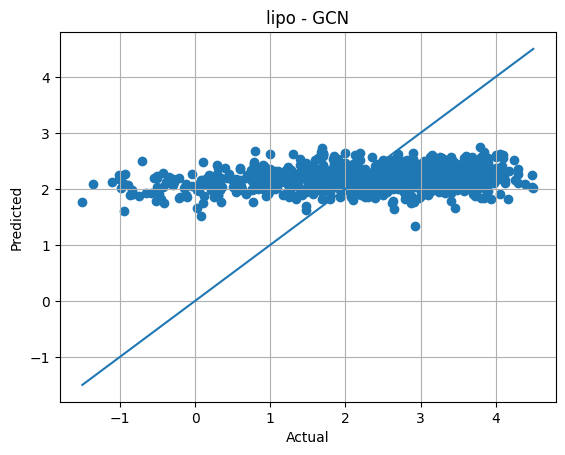

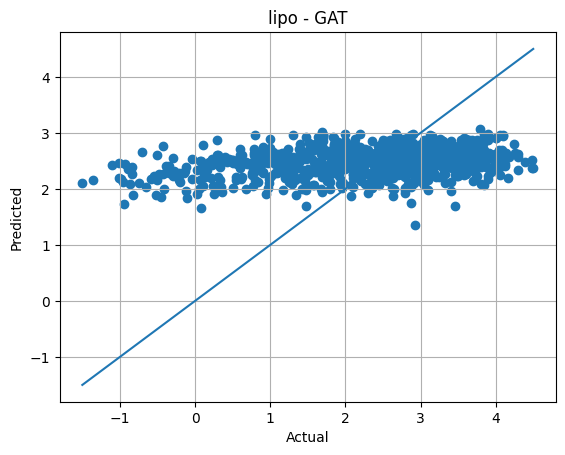

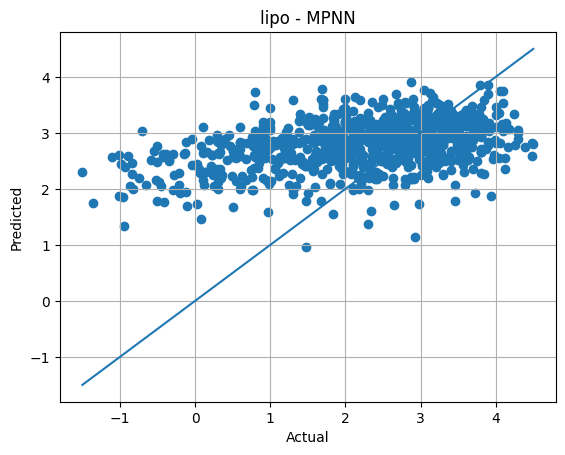

In [23]:
for dname in results:
    for mname in results[dname]:
        actual, pred = results[dname][mname][1:]

        plt.figure()
        plt.scatter(actual, pred)

        min_val = min(actual)
        max_val = max(actual)
        plt.plot([min_val, max_val], [min_val, max_val])

        plt.title(f"{dname} - {mname}")
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.grid()
        plt.show()

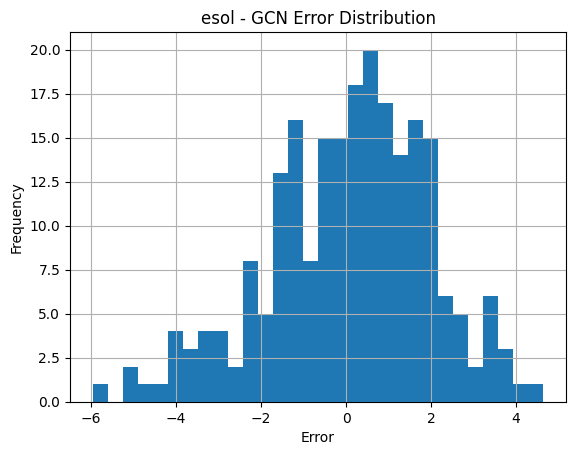

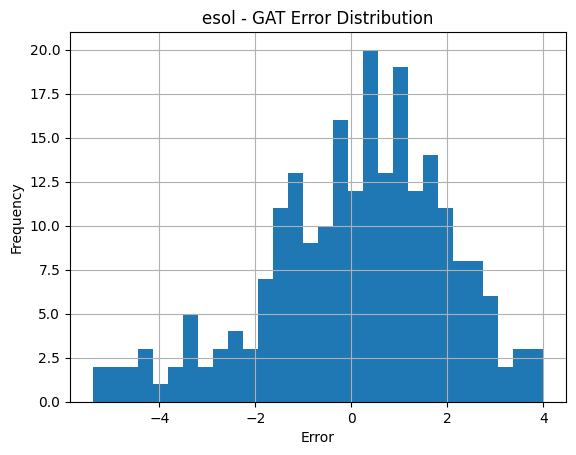

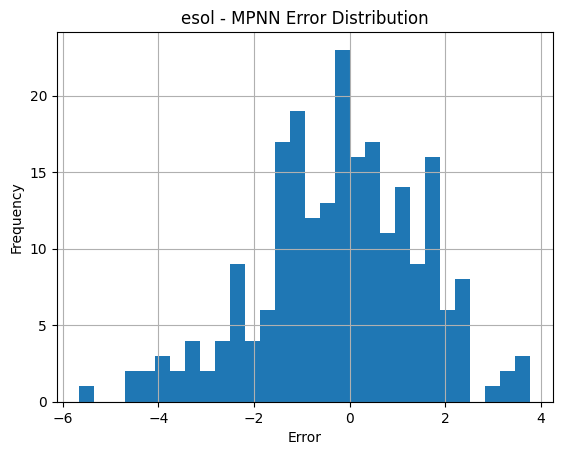

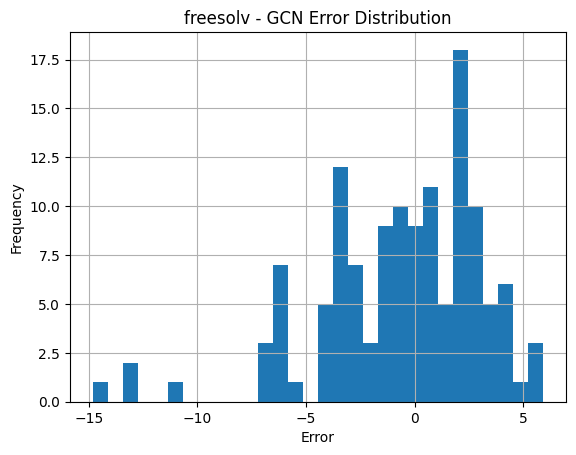

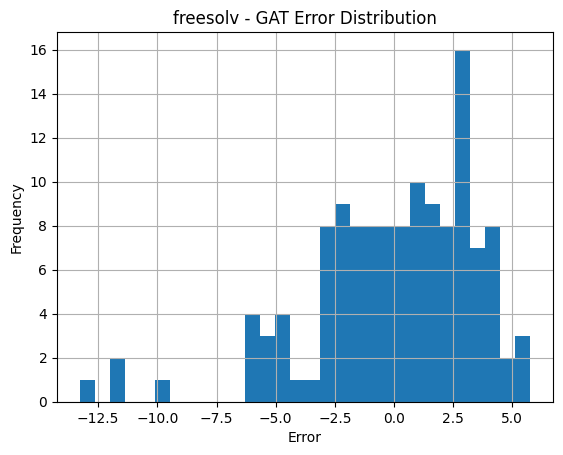

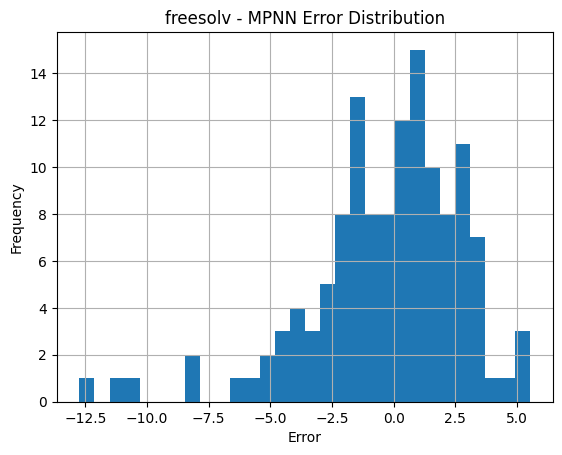

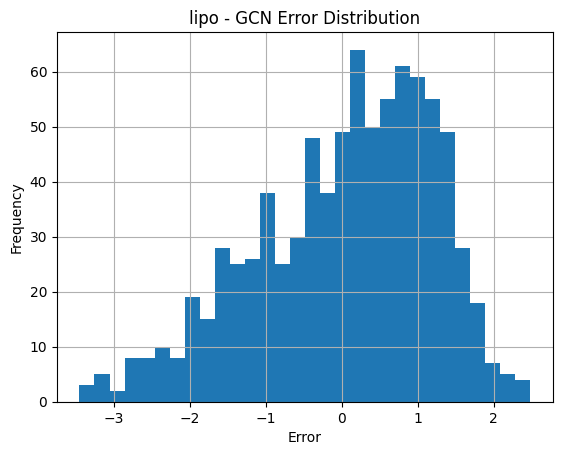

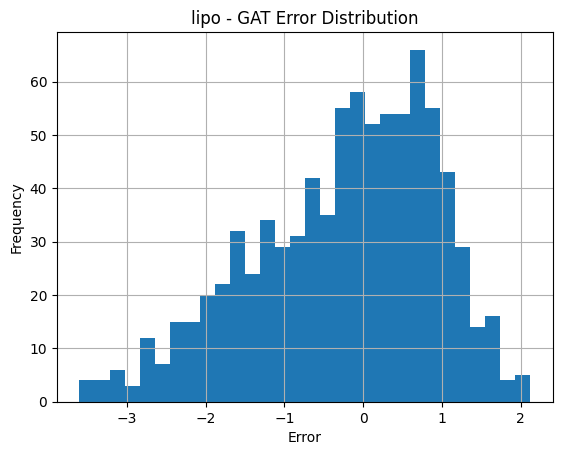

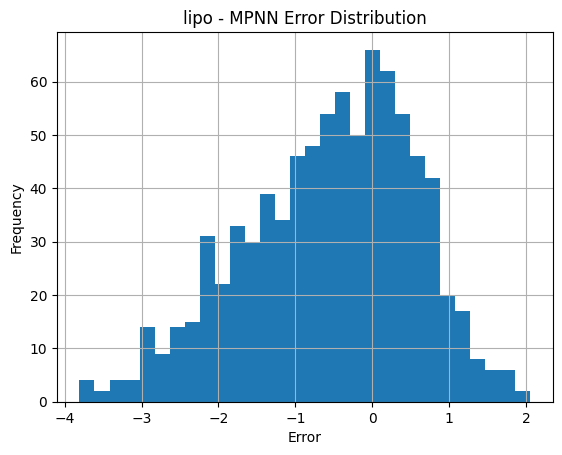

In [24]:
for dname in results:
    for mname in results[dname]:
        actual, pred = results[dname][mname][1:]

        error = actual - pred

        plt.figure()
        plt.hist(error, bins=30)

        plt.title(f"{dname} - {mname} Error Distribution")
        plt.xlabel("Error")
        plt.ylabel("Frequency")
        plt.grid()
        plt.show()